In [ ]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    CoolingFluidInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel


# Define the parameters for the frost evaporator
params = FrostEvaporatorParameters(
    # Time
    time_step=1.0,  # [s]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    hydraulic_fan_power=50.0,  # [W]
    pressure_loss_fit_factor=1.0,  # [-]

    # Geometrie Parameters
    fin_spacing=0.005,  # [m]
    fin_height=0.3,  # [m]
    fin_length=0.4,  # [m]
    fin_thickness=0.0002,  # [m]
    fin_amount=60,  # [-]
    tube_outer_diameter=0.01,  # [m]
    tube_inner_diameter=0.009,  # [m]
    tube_amount=8,  # [-]
    tubes_per_layer=2,  # [-]
)

# Define the inputs for the frost evaporator
air_inputs = AirInputs(
    T_in  = 273.15,  # [K]
    p_in  = 101325.0,  # [Pa]
    W_in  = 0.001,  # [kg/kg]
    )

fluid_inputs = CoolingFluidInputs()

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    fluid_inputs = fluid_inputs
)


# Create the models
frost_model = FrostModel(params)
air_model   = AirModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("m_dot_frost_flux", 2e-4) # kg/m^2/s
state.hmt.set("T_frost_surface", 270)

state.air.T_out = 300
state.air.W_out = 0.005
state.air.reynolds = 2000

frost_model.step_forward(state, inputs)

# Loop zum Konvergieren
for i in range(10):
    frost_model.update_properties(state, inputs)
    air_model.update_properties(state, inputs)

    print(state.air.p_in)

print(state.air)

101436.65418427544
101436.67568728961
101436.67569142999
101436.67569143079
101436.67569143079
101436.67569143079
101436.67569143079
101436.67569143079
101436.67569143079
101436.67569143079
AirState:
T_out=273.15 K (Outlet air temperature)
W_out=0.0 kg/kg (Outlet air absolute humidity)
p_in=101436.67569143079 Pa (Inlet air pressure)
delta_p=0.0 Pa (Air-side pressure drop)
pressure_avg=101380.8378457154 Pa (Average air pressure)
density_avg=1.2336175954631399 kg/m^3 (Average air density)
dyn_viscosity_avg=1.7851424334448386e-05 Pa*s (Average dynamic viscosity)
heat_capacity_avg=1008.6107242673559 J/kg/K (Average heat capacity)
thermal_conductivity_avg=0.025368444628807843 W/m/K (Average thermal conductivity)
prandtl_avg=0.709847989954393 - (Average Prandtl number)
lewis_avg=0.85 - (Average Lewis number)
rho_w_avg=0.003565364248835831 kg/m^3 (Average water vapor density)
rho_w_frost_sat=0.0037906551302693873 kg/m^3 (Saturation water vapor density at frost surface temperature)
reynolds=18

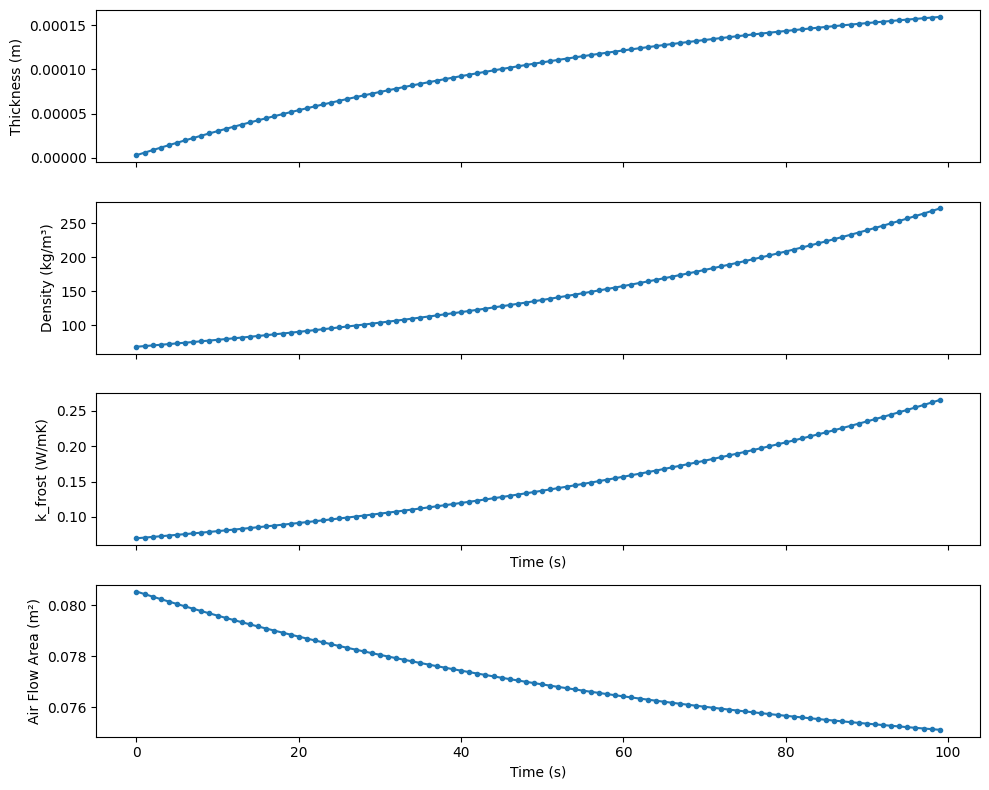

In [10]:
# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("m_dot_frost_flux", 2e-4) # kg/m^2/s

# Temperature sweep from 265K to 270K
temperatures_frost = np.linspace(265, 270, 100)

# Arrays to store results
thicknesses = []
densitys    = []
k_frosts    = []
flow_areas_air        = []

for T_frost in temperatures_frost:
    # Update the Frost Temperature - would be done by hmt.py
    state.hmt.set("T_frost_surface", T_frost)

    # Blue Boxes (This will be in a Iterative Loop later)
    frost_model.update_properties(state, inputs)

    # Green Boxes (Update after 1s timestep)
    frost_model.step_forward(state, inputs)

    # Store the results
    thicknesses.append(state.frost.thickness)
    densitys.append(state.frost.density)
    k_frosts.append(state.frost.k_frost)
    flow_areas_air.append(state.frost.flow_area_air)



fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(thicknesses, marker='.', linestyle='-')
axs[0].set_ylabel("Thickness (m)")

axs[1].plot(densitys, marker='.', linestyle='-')
axs[1].set_ylabel("Density (kg/m³)")

axs[2].plot(k_frosts, marker='.', linestyle='-')
axs[2].set_ylabel("k_frost (W/mK)")
axs[2].set_xlabel("Time (s)")

axs[3].plot(flow_areas_air, marker='.', linestyle='-')
axs[3].set_ylabel("Air Flow Area (m²)")
axs[3].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [ ]:
import CoolProp.CoolProp as CP_HumidAir

# --- Define the Humid Air State (SI Units) ---
T_dry_bulb = 298.15      # 25 °C = 298.15 K
Pressure = 101325.0      # 101.325 kPa (standard atmospheric pressure)
Relative_Humidity = 0.60 # 60% Relative Humidity

# --- Calculate Properties using HAPropsSI() ---
# HAPropsSI('Output', 'Input1Name', Input1, 'Input2Name', Input2, 'Input3Name', Input3)

# 1. Calculate Humidity Ratio (W) [kg_water/kg_dry_air]
Humidity_Ratio = CP_HumidAir.HAPropsSI('W', 'T', T_dry_bulb, 'P', Pressure, 'R', Relative_Humidity)

# 2. Calculate Enthalpy (H) [J/kg_dry_air]
Enthalpy = CP_HumidAir.HAPropsSI('H', 'T', T_dry_bulb, 'P', Pressure, 'R', Relative_Humidity)

# --- Display Results ---
print(f"Dry-Bulb Temp: {T_dry_bulb - 273.15:.2f} °C")
print(f"Relative Humidity: {Relative_Humidity * 100:.0f} %")
print(f"Total Pressure: {Pressure/1000:.1f} kPa")
print("-" * 30)
print(f"Humidity Ratio (W): {Humidity_Ratio:.5e} kg_water/kg_dry_air")
print(f"Specific Enthalpy (H): {Enthalpy / 1000:.2f} kJ/kg_dry_air")

# Example of a backward calculation: Find Dew-Point Temperature (D)
Dew_Point_Temp_K = CP_HumidAir.HAPropsSI('D', 'T', T_dry_bulb, 'P', Pressure, 'R', Relative_Humidity)
print(f"Dew Point Temp: {Dew_Point_Temp_K - 273.15:.2f} °C")

import CoolProp.CoolProp as CP_HumidAir
print(calculate_air_averages_compact(300, 101325.0, 1e-3, 350, 101525.0, 1e-2))

In [14]:

def get_air_properties(T, p, X):
    """Calculates multiple moist air properties for a single state."""
    
    properties = {}
    # List of properties to calculate
    # Vha: specific Volume per humid air, mu: Dynamic Viscosity, cp_ha: Heat Capacity, k: Thermal Conductivity
    prop_list = ['Vha', 'mu', 'cp_ha', 'k'] 
    
    # Calculate all properties in a loop
    for prop in prop_list:
        # One HAPropsSI call per property
        properties[prop] = CP_HumidAir.HAPropsSI(prop, 'T', T, 'P', p, 'W', X) 

    properties['Density'] = 1 / properties['Vha']  # Convert specific volume to density

    # Prandtl Number: Pr = (cp_ha * mu) / k
    properties['Prandtl'] = (properties['cp_ha'] * properties['mu']) / properties['k']

    # Lewis Number cant be calculated by CoolProp (Diffusivity is missing)
    properties['Lewis'] = 0.85
        
    # Return as a simple tuple for easy unpacking in the main function
    return (
        properties['Density'], 
        properties['mu'], 
        properties['cp_ha'], 
        properties['k'], 
        properties['Prandtl'], 
        properties['Lewis']
    )

def calculate_air_averages_compact(T_in, p_in, X_in, T_out, p_out, X_out):
    # Get all properties for inlet and outlet in two compact calls
    rho_in,  mu_in,  cp_in,  k_in,  prandtl_in,  lewis_in  = get_air_properties(T_in,  p_in,  X_in)
    rho_out, mu_out, cp_out, k_out, prandtl_out, lewis_out = get_air_properties(T_out, p_out, X_out)

    # Calculate averages
    density_average = (rho_in + rho_out) / 2
    dyn_viscosity_average = (mu_in + mu_out) / 2
    heat_capacity_average = (cp_in + cp_out) / 2
    thermal_conductivity_average = (k_in + k_out) / 2
    prandtl_average = (prandtl_in + prandtl_out) / 2
    lewis_average = (lewis_in + lewis_out) / 2
    

    return density_average, dyn_viscosity_average, heat_capacity_average, thermal_conductivity_average, prandtl_average, lewis_average

In [ ]:
CP_HumidAir.HAPropsSI('Vha', 'T', 300, 'P', 101325, 'W', 1e-3) 
